## Read Data

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def read_tec_data(file_path):
    """Read TEC data file and return a pandas DataFrame."""
    columns = ['Week', 'GPS_TOW', 'PRN', 'Az', 'Elv', 'L1CN0', 'S4', 'S4Cor', 
              'TEC30', 'TECRate30', 'L1LockTime', 'L2LockTime', 'L2CN0']
    
    df = pd.read_csv(file_path, names=columns, delimiter=',')
    
    # Convert relevant columns to numeric (you can add more if needed)
    for col in ['TEC30', 'TECRate30', 'GPS_TOW', 'Az', 'Elv', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Path to the data directory
data_dir = "../Data/TEC_2D_Data/One_Day_Data"

# Get all .dat files
data_files = glob.glob(os.path.join(data_dir, "*.dat"))

for file_path in data_files:
    # Extract station ID from filename
    station_id = os.path.basename(file_path).split('_')[0]
    
    # Read data
    print(f"Processing station {station_id}...")
    data = read_tec_data(file_path)

    # Print basic statistics
    print(f"\nStation {station_id} Statistics:")
    print(f"Number of satellites: {len(data['PRN'].unique())}")
    print(f"Time span: {data['GPS_TOW'].max() - data['GPS_TOW'].min()} seconds")
    print(f"Average TEC: {data['TEC30'].mean():.2f} TECU")
    print(f"Max TEC: {data['TEC30'].max():.2f} TECU")
    print(f"Min TEC: {data['TEC30'].min():.2f} TECU")
    print("-" * 50)


Processing station 124...

Station 124 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 33.91 TECU
Max TEC: 139.99 TECU
Min TEC: 0.00 TECU
--------------------------------------------------
Processing station 212...

Station 212 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 32.39 TECU
Max TEC: 141.03 TECU
Min TEC: 0.00 TECU
--------------------------------------------------
Processing station 213...

Station 213 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 32.18 TECU
Max TEC: 117.15 TECU
Min TEC: -4.22 TECU
--------------------------------------------------
Processing station 214...

Station 214 Statistics:
Number of satellites: 30
Time span: 86400.0 seconds
Average TEC: 31.82 TECU
Max TEC: 156.96 TECU
Min TEC: -9.90 TECU
--------------------------------------------------
Processing station 301...

Station 301 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 52.32 TECU

## Extracting Lat, Lon, Eca 



---

### ✅ **Formulas** 

1. **ECA**:

   $$
   \text{eca} = \frac{\pi}{2} - \text{el}_{\text{sat}} - \sin^{-1} \left( \frac{r_e \cdot \cos(\text{el}_{\text{sat}})}{r_e + h_I} \right)
   $$

2. **IPP\_lat**:

   $$
   \text{IPP}_{\text{lat}} = \sin^{-1} \left( \sin(R_{\text{lat}})\cos(\text{eca}) + \cos(R_{\text{lat}})\sin(\text{eca})\cos(\text{az}_{\text{sat}}) \right)
   $$

3. **IPP\_lon**:

   $$
   \text{IPP}_{\text{lon}} = R_{\text{lon}} + \frac{\sin^{-1}(\sin(\text{eca}) \cdot \sin(\text{az}_{\text{sat}}))}{\cos(\text{IPP}_{\text{lat}})}
   $$

---

### 📌 Required Parameters

* `el_sat` → `Elv` column (in degrees) → convert to radians
* `az_sat` → `Az` column (in degrees) → convert to radians
* `R_lat`, `R_lon` → receiver (station) lat/lon (constants per file or passed externally)
* `r_e` = 6371 km (mean Earth radius)
* `h_I` = 350 km (typical ionospheric shell height)

---

In [9]:
import pandas as pd
import numpy as np
import glob, os

def read_tec_data(file_path):
    columns = ['Week', 'GPS_TOW', 'PRN', 'Az', 'Elv', 'L1CN0', 'S4', 'S4Cor', 
               'TEC30', 'TECRate30', 'L1LockTime', 'L2LockTime', 'L2CN0']
    df = pd.read_csv(file_path, names=columns, delimiter=',', skiprows=1)
    for col in ['Az', 'Elv', 'TEC30', 'TECRate30', 'GPS_TOW', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def compute_ipp(df, R_lat_deg, R_lon_deg, h_I=350, r_e=6371):
    # Convert degrees to radians
    R_lat = np.radians(R_lat_deg)
    R_lon = np.radians(R_lon_deg)
    el = np.radians(df['Elv'])
    az = np.radians(df['Az'])

    # ECA calculation
    term = (r_e * np.cos(el)) / (r_e + h_I)
    eca = (np.pi / 2) - el - np.arcsin(term)

    # IPP latitude
    IPP_lat = np.arcsin(np.sin(R_lat) * np.cos(eca) + 
                        np.cos(R_lat) * np.sin(eca) * np.cos(az))

    # IPP longitude
    delta_lon = np.arcsin(np.sin(eca) * np.sin(az)) / np.cos(IPP_lat)
    IPP_lon = R_lon + delta_lon

    # Convert radians to degrees
    df['ECA'] = np.degrees(eca)
    df['IPP_lat'] = np.degrees(IPP_lat)
    df['IPP_lon'] = np.degrees(IPP_lon)
    return df

# ---- MAIN SCRIPT ----
data_dir = "../Data/TEC_2D_Data/One_Day_Data"
output_dir = "../Data/GenData/Processed_TEC_with_IPP"
os.makedirs(output_dir, exist_ok=True)

data_files = glob.glob(os.path.join(data_dir, "*.dat"))

# 🔧 You must set the receiver's latitude and longitude for each station
station_coords = {
    "stationA": (23.2, 77.5),   # Example: Bhopal
    "stationB": (28.6, 77.2),   # Example: Delhi
    # Add more if needed
}

for file_path in data_files:
    station_id = os.path.basename(file_path).split('_')[0]
    print(f"Processing station {station_id}...")

    data = read_tec_data(file_path)

    # Get station lat/lon or default
    R_lat, R_lon = station_coords.get(station_id, (23.0, 78.0))  # default to MP center

    # Compute IPP and ECA
    data = compute_ipp(data, R_lat, R_lon)

    # Save to new directory
    new_file = os.path.join(output_dir, f"{station_id}_with_IPP.csv")
    data.to_csv(new_file, index=False)
    print(f"Saved processed file to: {new_file}")


Processing station 124...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\124_with_IPP.csv
Processing station 212...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\212_with_IPP.csv
Processing station 213...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\213_with_IPP.csv
Processing station 214...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\214_with_IPP.csv
Processing station 301...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\301_with_IPP.csv
Processing station 302...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\302_with_IPP.csv
Processing station 305...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\305_with_IPP.csv
Processing station 306...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\306_with_IPP.csv
Processing station 307...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\307_with_IPP.csv
Processing station 308...
Saved proce

## Filter Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
import numpy as np

def read_tec_data(file_path):
    df = pd.read_csv(file_path)  # Use headers from the file
    
    # Apply elevation cutoff
    df = df[df['Elv'] >= 25]
    
    # Convert required columns to numeric (just in case)
    for col in ['Az', 'Elv', 'TEC30', 'TECRate30', 'GPS_TOW', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

def plot_tec_data(data, station_id, base_output="../Output"):
    unique_prns = sorted(data['PRN'].unique())
    cmap = cm.get_cmap('tab20', len(unique_prns))

    # Ensure output subfolders exist
    os.makedirs(os.path.join(base_output, "TEC_TimeSeries"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "S4_Scintillation"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "Sky_Plot"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "TEC_Rate"), exist_ok=True)

    # ---------- Plot 1: TEC Time Series ----------
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax1.scatter(prn_data['GPS_TOW'], prn_data['TEC30'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax1.set_title(f'TEC Values Over Time - Station {station_id}')
    ax1.set_xlabel('GPS Time of Week (seconds)')
    ax1.set_ylabel('TEC (TECU)')
    ax1.set_ylim(0, 120)  # Set y-axis range from 0 to 120
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    fig1.tight_layout()
    fig1.savefig(os.path.join(base_output, "TEC_TimeSeries", f"{station_id}_tec.png"), dpi=300, bbox_inches='tight')
    plt.close(fig1)

    # ---------- Plot 2: S4 Scintillation ----------
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax2.scatter(prn_data['GPS_TOW'], prn_data['S4'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax2.set_title(f'S4 Scintillation Index - Station {station_id}')
    ax2.set_xlabel('GPS Time of Week (seconds)')
    ax2.set_ylabel('S4 Index')
    ax2.set_ylim(0.15, )  # Set y-axis range 
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    fig2.tight_layout()
    fig2.savefig(os.path.join(base_output, "S4_Scintillation", f"{station_id}_s4.png"), dpi=300, bbox_inches='tight')
    plt.close(fig2)

    # ---------- Plot 3: Polar Sky Plot ----------
    fig3 = plt.figure(figsize=(8, 8))
    ax3 = fig3.add_subplot(111, polar=True)
    az_rad = np.radians(data['Az'])
    el_adj = 90 - data['Elv']
    sc = ax3.scatter(az_rad, el_adj, c=data['TEC30'], cmap='viridis', s=20)
    ax3.set_title(f'Polar Sky Plot - Station {station_id}', pad=20)
    plt.colorbar(sc, ax=ax3, label='TEC (TECU)', pad=0.1)
    ax3.set_theta_zero_location('N')
    ax3.set_theta_direction(-1)
    ax3.set_rgrids([0, 30, 60], labels=["90°", "60°", "30°"], angle=22.5)
    ax3.set_thetagrids(range(0, 360, 45), labels=[f'{ang}°' for ang in range(0, 360, 45)])
    fig3.tight_layout()
    fig3.savefig(os.path.join(base_output, "Sky_Plot", f"{station_id}_sky.png"), dpi=300, bbox_inches='tight')
    plt.close(fig3)

    # ---------- Plot 4: TEC Rate ----------
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax4.scatter(prn_data['GPS_TOW'], prn_data['TECRate30'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax4.set_title(f'TEC Rate - Station {station_id}')
    ax4.set_xlabel('GPS Time of Week (seconds)')
    ax4.set_ylabel('TEC Rate (TECU/min)')
    ax4.set_ylim(-1.5, 1.5)  # Set y-axis range from -1.5 to 1.5
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    fig4.tight_layout()
    fig4.savefig(os.path.join(base_output, "TEC_Rate", f"{station_id}_tec_rate.png"), dpi=300, bbox_inches='tight')
    plt.close(fig4)

# Path to the data directory
data_dir = "../Data/GenData/Processed_TEC_with_IPP"

# Get all .csv files
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

for file_path in data_files:
    station_id = os.path.basename(file_path).split('_')[0]
    print(f"Processing station {station_id}...")
    
    data = read_tec_data(file_path)
    
    if data.empty:
        print(f"⚠️  Station {station_id}: No valid data after elevation filter. Skipping...\n" + "-"*50)
        continue

    # Create and save plots
    plot_tec_data(data, station_id)
    
    # Print basic statistics
    print(f"\nStation {station_id} Statistics:")
    print(f"Number of satellites: {len(data['PRN'].unique())}")
    print(f"Time span: {data['GPS_TOW'].max() - data['GPS_TOW'].min()} seconds")
    print(f"Average TEC: {data['TEC30'].mean():.2f} TECU")
    print(f"Max TEC: {data['TEC30'].max():.2f} TECU")
    print(f"Min TEC: {data['TEC30'].min():.2f} TECU")
    print("-" * 50)



Processing station 213...


/tmp/ipykernel_87007/3974935500.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 213 Statistics:
Number of satellites: 28
Time span: 86400 seconds
Average TEC: 28.43 TECU
Max TEC: 80.79 TECU
Min TEC: -3.81 TECU
--------------------------------------------------
Processing station 313...


/tmp/ipykernel_87007/3974935500.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 313 Statistics:
Number of satellites: 28
Time span: 86400 seconds
Average TEC: 47.26 TECU
Max TEC: 121.88 TECU
Min TEC: 9.12 TECU
--------------------------------------------------
Processing station 302...


...


Station 308 Statistics:
Number of satellites: 28
Time span: 86400 seconds
Average TEC: 30.89 TECU
Max TEC: 81.70 TECU
Min TEC: -2.43 TECU
--------------------------------------------------
Processing station 311...


/tmp/ipykernel_87007/3974935500.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 311 Statistics:
Number of satellites: 28
Time span: 69600 seconds
Average TEC: 49.03 TECU
Max TEC: 112.74 TECU
Min TEC: 5.52 TECU
--------------------------------------------------
Processing station 124...


/tmp/ipykernel_87007/3974935500.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 124 Statistics:
Number of satellites: 28
Time span: 86400 seconds
Average TEC: 30.38 TECU
Max TEC: 113.64 TECU
Min TEC: 1.67 TECU
--------------------------------------------------


## ROI

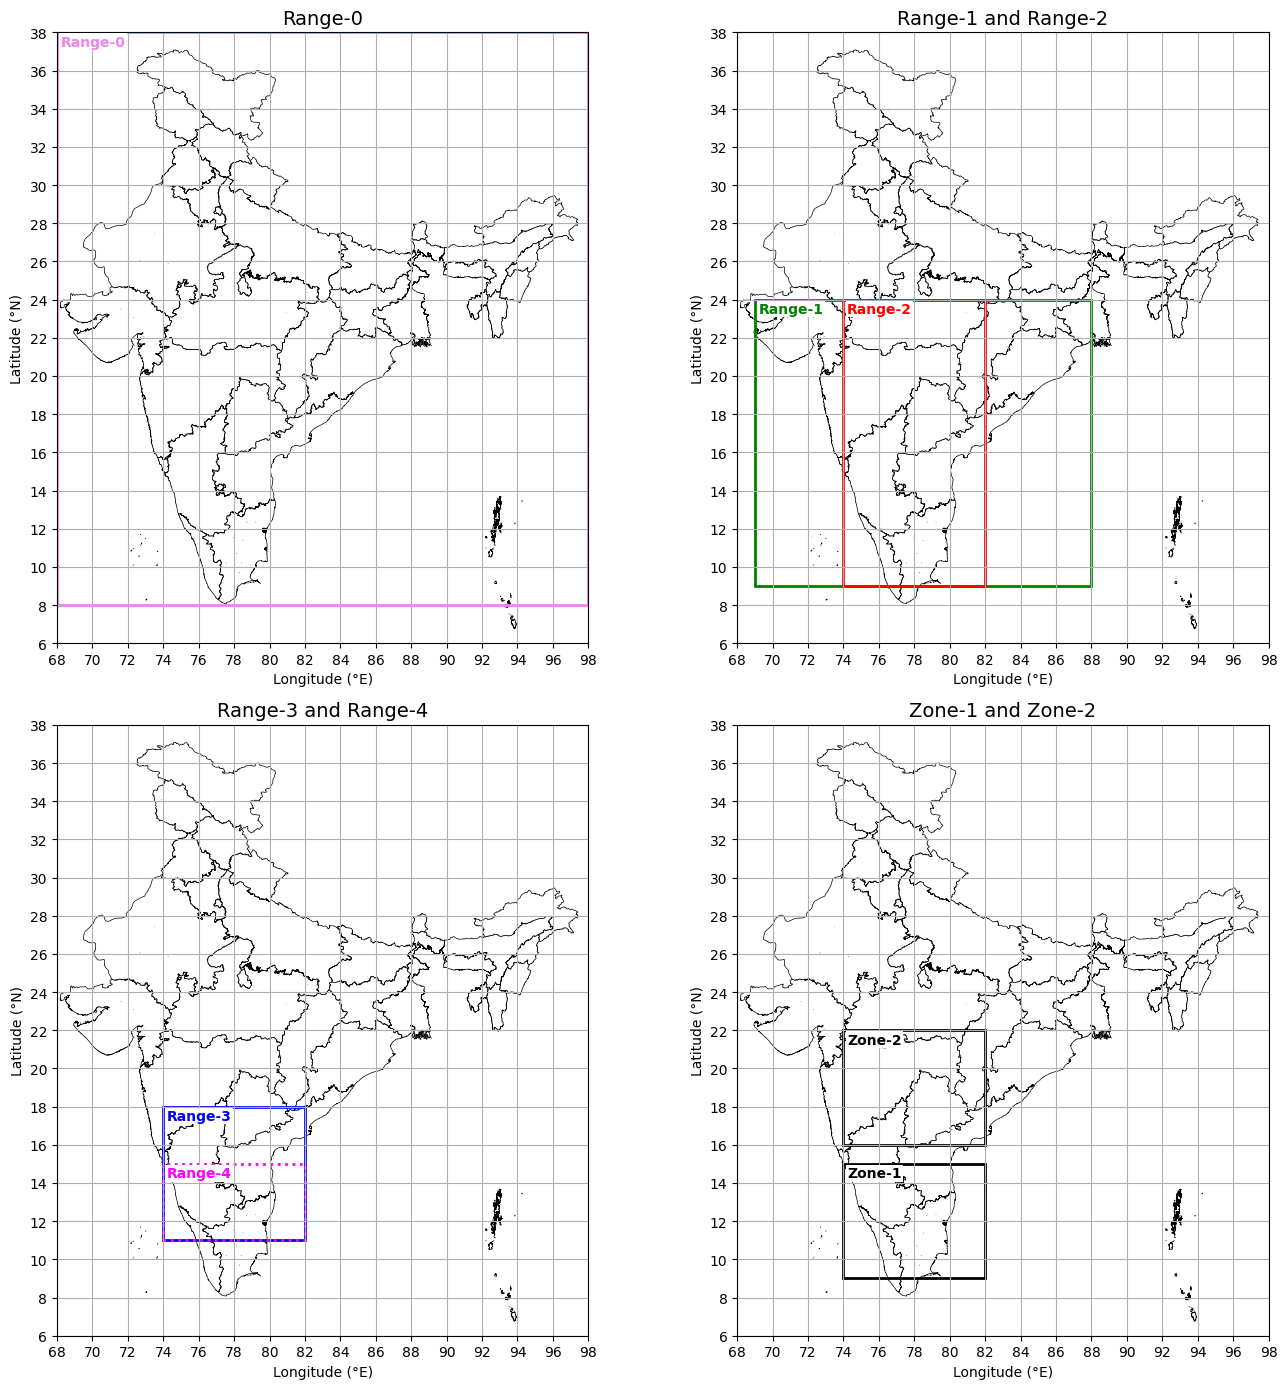

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker

# Load and reproject the state-level shapefile of India to WGS84
shapefile_path = "../Data/shapefiles/STATE_BOUNDARY.shp"
gdf = gpd.read_file(shapefile_path)

# Ensure CRS is WGS84 (lat/lon)
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Define bounding boxes: (lon_min, lon_max, lat_min, lat_max)
regions = {
    'Range-0': {'bounds': (68, 98, 8, 38), 'color': 'violet'},
    'Range-1': {'bounds': (69, 88, 9, 24), 'color': 'green'},
    'Range-2': {'bounds': (74, 82, 9, 24), 'color': 'red'},
    'Range-3': {'bounds': (74, 82, 11, 18), 'color': 'blue'},
    'Range-4': {'bounds': (74, 82, 11, 15), 'color': 'magenta', 'linestyle': 'dotted'},
    'Zone-1':  {'bounds': (74, 82, 9, 15), 'color': 'black'},
    'Zone-2':  {'bounds': (74, 82, 16, 22), 'color': 'black'},
}

# Subplot layout
fig, axs = plt.subplots(2, 2, figsize=(14, 14))
axs = axs.flatten()

subplot_regions = [
    ['Range-0'],
    ['Range-1', 'Range-2'],
    ['Range-3', 'Range-4'],
    ['Zone-1', 'Zone-2']
]
titles = [
    "Range-0",
    "Range-1 and Range-2",
    "Range-3 and Range-4",
    "Zone-1 and Zone-2"
]

for ax, group, title in zip(axs, subplot_regions, titles):
    # Plot base India map
    gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

    # Plot bounding boxes and labels
    for region in group:
        lon_min, lon_max, lat_min, lat_max = regions[region]['bounds']
        width = lon_max - lon_min
        height = lat_max - lat_min
        linestyle = regions[region].get('linestyle', 'solid')
        
        # Draw rectangle
        rect = Rectangle((lon_min, lat_min), width, height,
                         linewidth=2, edgecolor=regions[region]['color'],
                         facecolor='none', linestyle=linestyle)
        ax.add_patch(rect)
        
        # Add label at top-left corner
        ax.text(lon_min + 0.2, lat_max - 0.7, region,
                fontsize=10, color=regions[region]['color'],
                weight='bold', bbox=dict(facecolor='white', edgecolor='none', pad=1))

    # Set axis limits and labels
    ax.set_xlim(68, 98)
    ax.set_ylim(6, 38)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

    # Mark ticks at every 2 degrees
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.grid(True)

plt.tight_layout()
plt.show()
